<a href="https://colab.research.google.com/github/amathie5/projet-breast-cancer/blob/main/datascience_project_breastcancer_vfinal1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
#CSV files importation
df1 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df1.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df2.csv')
df3 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df3.csv')

#Concatening all dataframes together to be left with one unique dataframe
df = pd.concat([df1,df2,df3]).sort_values(by='year')
df_encoded = df.copy()

#Displaying the head of the dataset
display(df.head())

# Number of variables (columns)
num_variables = df.shape[1]

# Number of observations (lines)
num_observations = df.shape[0]

# Total number of values
total_values = df.size  # équivalent à num_variables * num_observations

# Affichage
print(f'The dataset contains a total of {num_variables} variables and {num_observations} observations, for a total of {total_values} values')
print(f'The dataset contains no null value and every variable is of type int64')
display(df.info())



,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
20,2005,1,1,0,1,0,2,0,1,1,0,0,1
19,2005,1,1,0,0,9,4,0,1,9,9,9,1
18,2005,1,1,0,0,9,4,0,1,1,0,0,1
7,2005,1,1,0,0,4,2,0,1,1,0,0,1
6,2005,1,1,0,0,2,3,0,1,9,0,0,1


The dataset contains a total of 13 variables and 1522340 observations, for a total of 19790420 values
The dataset contains no null value and every variable is of type int64
<class 'pandas.core.frame.DataFrame'>
Index: 1522340 entries, 20 to 411300
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype
---  ------                 --------------    -----
 0   year                   1522340 non-null  int64
 1   age_group_5_years      1522340 non-null  int64
 2   race_eth               1522340 non-null  int64
 3   first_degree_hx        1522340 non-null  int64
 4   age_menarche           1522340 non-null  int64
 5   age_first_birth        1522340 non-null  int64
 6   BIRADS_breast_density  1522340 non-null  int64
 7   current_hrt            1522340 non-null  int64
 8   menopaus               1522340 non-null  int64
 9   bmi_group              1522340 non-null  int64
 10  biophx                 1522340 non-null  int64
 11  breast_cancer_history  1522340 non-nul

None

In [3]:
age_map = {1:'18-29',2:'30-34',3:'35-39',4:'40-44',5:'45-49',6:'50-54',7:'55-59',8:'60-64',9:'65-69',10:'70-74',11:'75-79',12:'80-84',13:'85+'}
race_map = {1:'non-hispanic white', 2:'non-hispanic black', 3:'asian/pacific islander', 4:'native american',5:'hispanic',6:'other/mixed',9:'unknown'}
familyhx_map = {0:'no', 1:'yes', 9:'unknown'}
menarche_map = {0:'14+',1:'12-13',2:'<12',9:'unknown'}
firstbirth_map = {0:'<20',1:'20-24',2:'25-29',3:'30+',4:'nulliparous',9:'unknown'}
BIRADS_map = {1:'fatty',2:'scattered',3:'heterogeneously dense', 4:'extremely dense', 5:'unknown'}
hrt_map = {0:'no', 1:'yes',9:'unknown'}
menopaus_map = {1:'pre-menopausal',2:'post-menopausal',3:'surgical menopause', 9:'unknown'}
bmi_map = {1:'10-24.99',2:'25-29.99',3:'30-34.99',4:'35+',9:'unknown'}
biophx_map = {0:'no',1:'yes', 9:'unknown'}
history_map = {0:'no',1:'yes',9:'unknown'}

#Replacing the code with the categories
df['age_group_5_years']=df['age_group_5_years'].map(age_map)
df['race_eth']=df['race_eth'].map(race_map)
df['first_degree_hx']=df['first_degree_hx'].map(familyhx_map)
df['age_menarche']=df['age_menarche'].map(menarche_map)
df['age_first_birth']=df['age_first_birth'].map(firstbirth_map)
df['BIRADS_breast_density']=df['BIRADS_breast_density'].map(BIRADS_map)
df['current_hrt']=df['current_hrt'].map(hrt_map)
df['menopaus']=df['menopaus'].map(menopaus_map)
df['bmi_group']=df['bmi_group'].map(bmi_map)
df['biophx']=df['biophx'].map(biophx_map)
df['breast_cancer_history']=df['breast_cancer_history'].map(history_map)

#convert as category
cat_cols = ['age_group_5_years','race_eth','first_degree_hx','age_menarche','age_first_birth','BIRADS_breast_density','current_hrt','menopaus','bmi_group','biophx','breast_cancer_history']
df[cat_cols] = df[cat_cols].astype('category')
display(df.head())
df.info()
df.isna().sum()




,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1
19,2005,18-29,non-hispanic white,no,14+,unknown,extremely dense,no,pre-menopausal,unknown,unknown,unknown,1
18,2005,18-29,non-hispanic white,no,14+,unknown,extremely dense,no,pre-menopausal,10-24.99,no,no,1
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1
6,2005,18-29,non-hispanic white,no,14+,25-29,heterogeneously dense,no,pre-menopausal,unknown,no,no,1


<class 'pandas.core.frame.DataFrame'>
Index: 1522340 entries, 20 to 411300
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   year                   1522340 non-null  int64   
 1   age_group_5_years      1522340 non-null  category
 2   race_eth               1522340 non-null  category
 3   first_degree_hx        1522340 non-null  category
 4   age_menarche           1522340 non-null  category
 5   age_first_birth        1522340 non-null  category
 6   BIRADS_breast_density  1343329 non-null  category
 7   current_hrt            1522340 non-null  category
 8   menopaus               1522340 non-null  category
 9   bmi_group              1522340 non-null  category
 10  biophx                 1522340 non-null  category
 11  breast_cancer_history  1522340 non-null  category
 12  count                  1522340 non-null  int64   
dtypes: category(11), int64(2)
memory usage: 50.8 MB


,0
year,0
age_group_5_years,0
race_eth,0
first_degree_hx,0
age_menarche,0
age_first_birth,0
BIRADS_breast_density,179011
current_hrt,0
menopaus,0
bmi_group,0


In [4]:
#replace unknown values by nan
df = df.replace('unknown',np.nan)


/tmp/ipython-input-1331537884.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df = df.replace('unknown',np.nan)


In [5]:
#create two binary variables for high BIRADS and cancer history
df['BIRADS_high']=np.where(df_encoded['BIRADS_breast_density'].isin([3,4]),1,0)
df['breast_cancer_history_bin']=np.where(df_encoded['breast_cancer_history']==1,1,0)

#check the distribution
display(df['BIRADS_high'])
display(df['breast_cancer_history_bin'])

display(df.head())

,BIRADS_high
20,0
19,1
18,1
7,0
6,1
...,...
411304,1
411303,1
411302,1
411301,1


,breast_cancer_history_bin
20,0
19,0
18,0
7,0
6,0
...,...
411304,0
411303,0
411302,0
411301,0


,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
19,2005,18-29,non-hispanic white,no,14+,NaN,extremely dense,no,pre-menopausal,NaN,NaN,NaN,1,1,0
18,2005,18-29,non-hispanic white,no,14+,NaN,extremely dense,no,pre-menopausal,10-24.99,no,no,1,1,0
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
6,2005,18-29,non-hispanic white,no,14+,25-29,heterogeneously dense,no,pre-menopausal,NaN,no,no,1,1,0


In [6]:
##integrity checks
#check that all frequency counts are positive integers
valid = (df["count"].apply(lambda x: isinstance(x, int) and x > 0)).all()
print('all frequency counts are positive integers: ', valid)

#check types and unique values
for col in cat_cols:
  print(col, ':',df[col].unique())

#check for duplicates
print('Duplicates: ', df.duplicated().sum())

#the total number of observations should be 6'788'436
print('Number of observations: ', df['count'].sum())


all frequency counts are positive integers:  True
age_group_5_years : ['18-29', '85+', '30-34', '35-39', '40-44', ..., '60-64', '65-69', '70-74', '75-79', '80-84']
Length: 13
Categories (13, object): ['18-29', '30-34', '35-39', '40-44', ..., '70-74', '75-79', '80-84', '85+']
race_eth : ['non-hispanic white', NaN, 'non-hispanic black', 'asian/pacific islander', 'hispanic', 'native american', 'other/mixed']
Categories (6, object): ['asian/pacific islander', 'hispanic', 'native american', 'non-hispanic black',
                         'non-hispanic white', 'other/mixed']
first_degree_hx : ['no', NaN, 'yes']
Categories (2, object): ['no', 'yes']
age_menarche : ['12-13', '14+', NaN, '<12']
Categories (3, object): ['12-13', '14+', '<12']
age_first_birth : ['<20', NaN, 'nulliparous', '25-29', '20-24', '30+']
Categories (5, object): ['20-24', '25-29', '30+', '<20', 'nulliparous']
BIRADS_breast_density : ['scattered', 'extremely dense', 'heterogeneously dense', NaN, 'fatty']
Categories (4, obje

In [7]:
df_cleaned = df.dropna()
df_cleaned.info()
display(df_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
Index: 345064 entries, 20 to 411300
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   year                       345064 non-null  int64   
 1   age_group_5_years          345064 non-null  category
 2   race_eth                   345064 non-null  category
 3   first_degree_hx            345064 non-null  category
 4   age_menarche               345064 non-null  category
 5   age_first_birth            345064 non-null  category
 6   BIRADS_breast_density      345064 non-null  category
 7   current_hrt                345064 non-null  category
 8   menopaus                   345064 non-null  category
 9   bmi_group                  345064 non-null  category
 10  biophx                     345064 non-null  category
 11  breast_cancer_history      345064 non-null  category
 12  count                      345064 non-null  int64   
 13  BIRADS_high       

,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
4,2005,18-29,non-hispanic white,no,14+,20-24,extremely dense,no,pre-menopausal,35+,no,no,1,1,0
2,2005,18-29,non-hispanic white,no,14+,<20,extremely dense,no,pre-menopausal,25-29.99,no,no,1,1,0
51,2005,18-29,non-hispanic white,no,<12,<20,scattered,no,pre-menopausal,30-34.99,no,no,1,0,0


In [8]:

df_cleaned_descr = df_cleaned.describe(include = 'all')
df_cleaned_descr['year'] = df_cleaned_descr['year'].round(0)
display(df_cleaned_descr)

,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
count,345064.0,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064.000000,345064.000000,345064.000000
unique,NaN,13,6,2,3,5,4,2,3,4,2,2,NaN,NaN,NaN
top,NaN,50-54,non-hispanic white,no,12-13,20-24,scattered,no,post-menopausal,10-24.99,no,no,NaN,NaN,NaN
freq,NaN,55940,160707,244775,146835,80181,128616,324839,203441,105624,211903,292132,NaN,NaN,NaN
mean,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.024227,0.491874,0.153398
std,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.468720,0.499935,0.360371
min,2005.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
25%,2008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
50%,2012.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
75%,2015.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,0.000000


Certaines combinaisons reviennent très fréquemment (1093 fois) alors que certains ne sont présente que une fois. En moyenne les combinaisons apparaissent 5,5 fois.
En moyenne 47,75% des femmes ont une densité mammaire élevée et 16,42% ont été diagnostiquées avec un cancer dans le passé.

/tmp/ipython-input-1928707795.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cleaned_agg = df_cleaned.groupby(cat_cols, as_index=False)['count'].sum()


,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
0,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,10-24.99,no,no,0
1,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,10-24.99,no,yes,0
2,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,10-24.99,yes,no,0
3,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,10-24.99,yes,yes,0
4,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,25-29.99,no,no,0


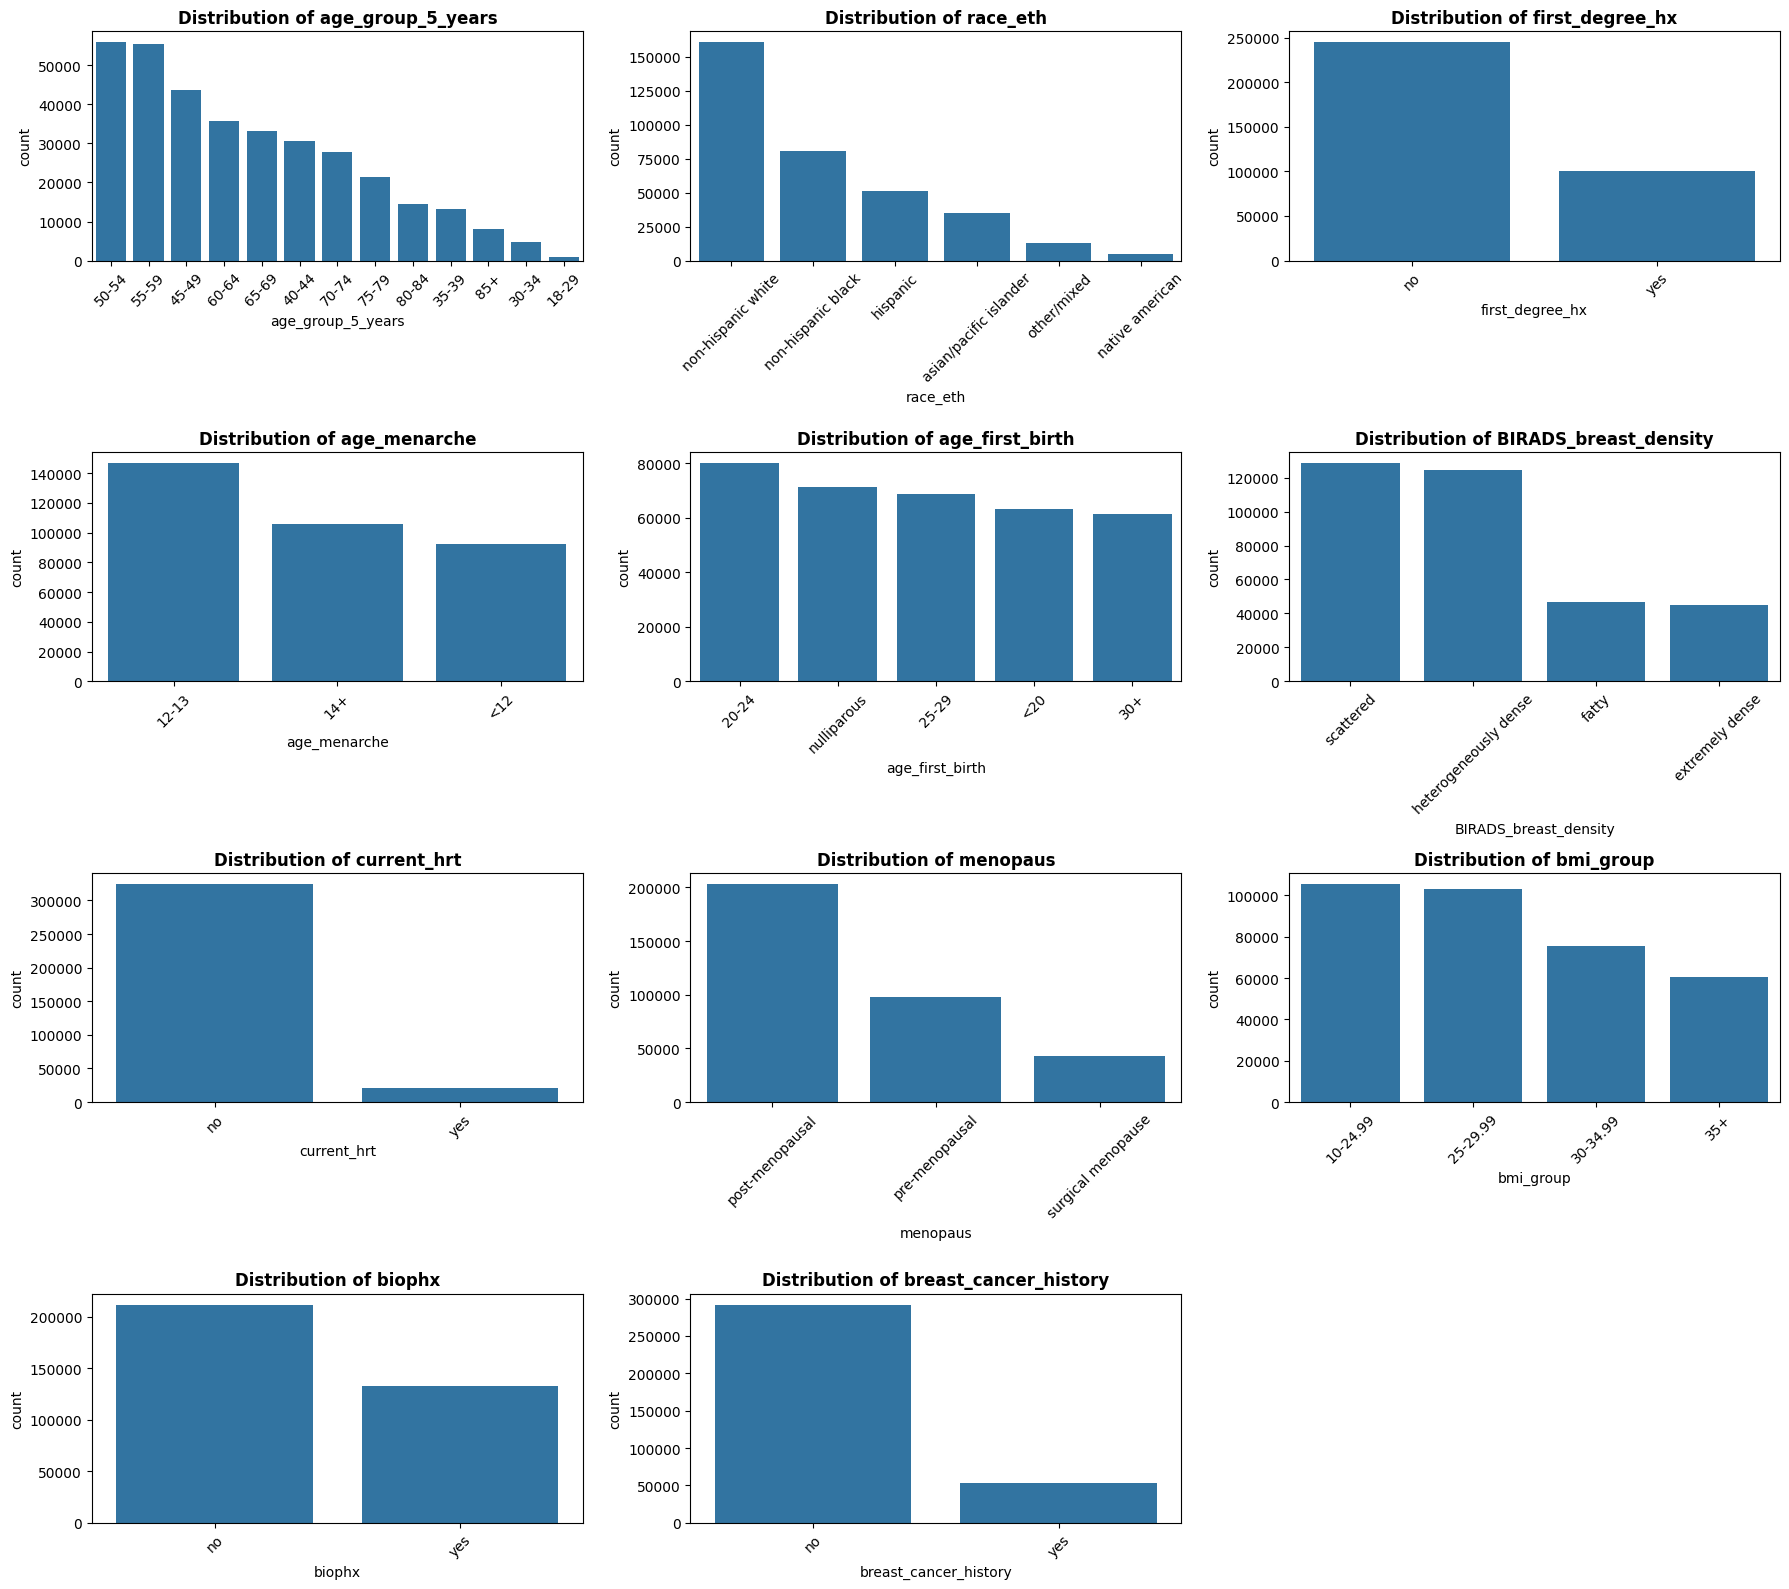

In [9]:
df_cleaned_agg = df_cleaned.groupby(cat_cols, as_index=False)['count'].sum()
display(df_cleaned_agg.head())

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_cleaned, x=col, ax=axes[i], order=df_cleaned[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

# Supprimer les axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



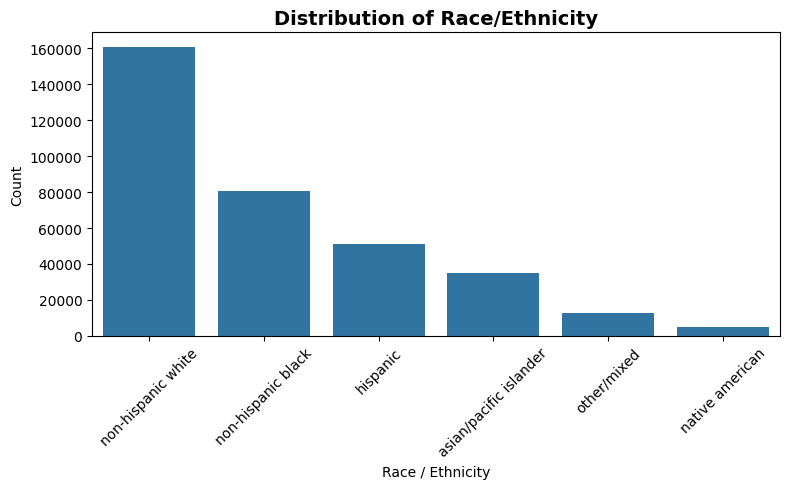

/tmp/ipython-input-3517702272.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_birads_bmi = (df_cleaned.groupby('bmi_group')['BIRADS_high'].mean().reset_index())


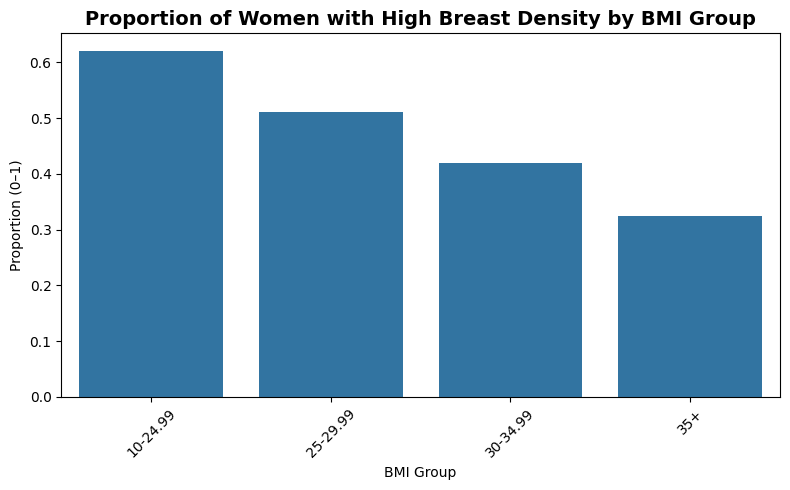

/tmp/ipython-input-3517702272.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_birads_age = (df_cleaned.groupby('age_group_5_years')['BIRADS_high'].mean().reset_index())


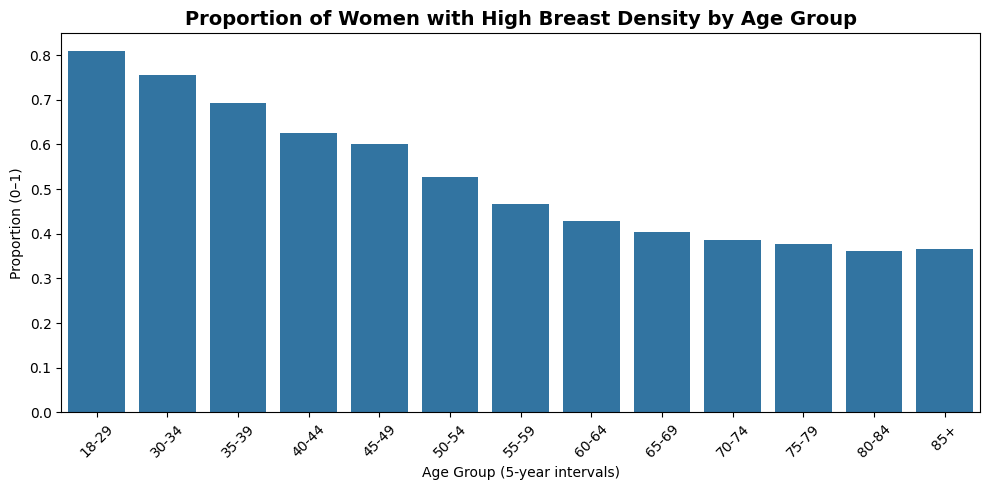

/tmp/ipython-input-3517702272.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_cancer_menop = (df_cleaned.groupby('menopaus').apply(lambda g: np.average(g['breast_cancer_history_bin'], weights=g['count'])).reset_index(name='prop_prior_cancer'))
/tmp/ipython-input-3517702272.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prop_cancer_menop = (df_cleaned.groupby('menopaus').apply(lambda g: np.average(g['breast_cancer_history_bin'], weights=g['count'])).reset_index(name='prop_prior_cancer'))


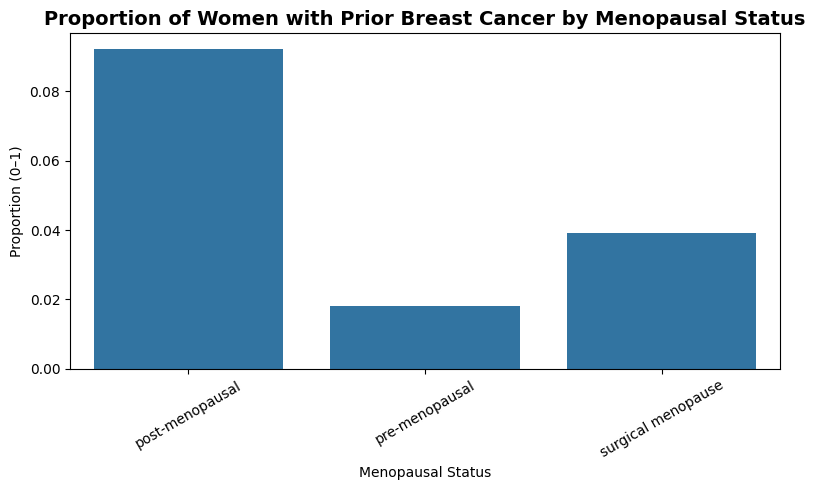

/tmp/ipython-input-3517702272.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_cancer_family = (df_cleaned.groupby('first_degree_hx').apply(lambda g: np.average(g['breast_cancer_history_bin'], weights=g['count'])).reset_index(name='prop_prior_cancer'))
/tmp/ipython-input-3517702272.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prop_cancer_family = (df_cleaned.groupby('first_degree_hx').apply(lambda g: np.average(g['breast_cancer_history_bin'], weights=g['count'])).reset_index(name='prop_prior

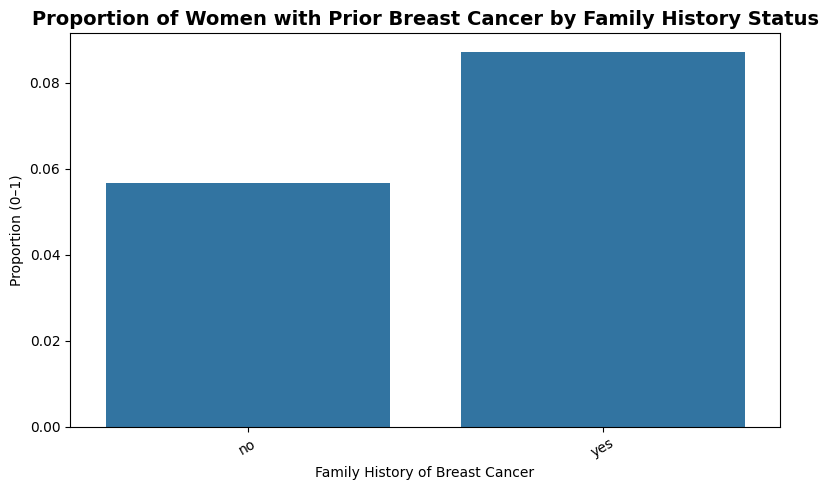

/tmp/ipython-input-3517702272.py:86: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_data = df_cleaned.groupby('year', as_index=False).apply(


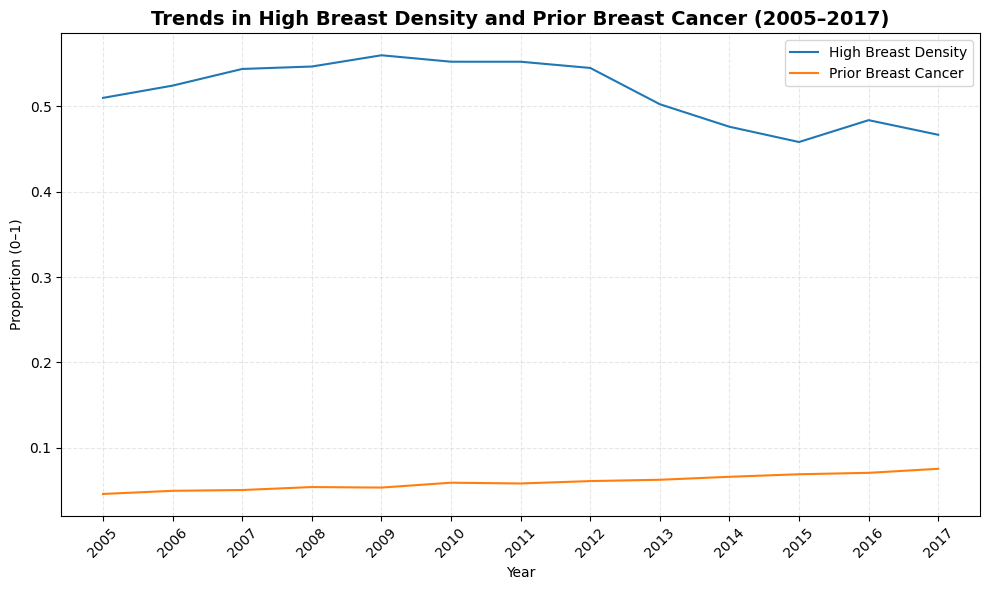

In [10]:
#Exhibit 1 - distribution of race ethnicity
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_cleaned,
    x='race_eth',
    order=df_cleaned['race_eth'].value_counts().index
)

plt.title("Distribution of Race/Ethnicity", fontsize=14, fontweight='bold')
plt.xlabel("Race / Ethnicity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Exhibit 2 - high breast density by BMI group
## Calculer la proportion
prop_birads_bmi = (df_cleaned.groupby('bmi_group')['BIRADS_high'].mean().reset_index())

plt.figure(figsize=(8,5))
sns.barplot(
    data=prop_birads_bmi,
    x='bmi_group',
    y='BIRADS_high'
)

plt.title("Proportion of Women with High Breast Density by BMI Group", fontsize=14, fontweight='bold')
plt.ylabel("Proportion (0–1)")
plt.xlabel("BMI Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Exhibit 3 - Proportion of women with high breast density by age group
prop_birads_age = (df_cleaned.groupby('age_group_5_years')['BIRADS_high'].mean().reset_index())

plt.figure(figsize=(10,5))
sns.barplot(
    data=prop_birads_age,
    x='age_group_5_years',
    y='BIRADS_high'
)

plt.title("Proportion of Women with High Breast Density by Age Group", fontsize=14, fontweight='bold')
plt.ylabel("Proportion (0–1)")
plt.xlabel("Age Group (5-year intervals)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Exhibit 4 - Proportion of women with prior breast cancer by menopausal status
prop_cancer_menop = (df_cleaned.groupby('menopaus').apply(lambda g: np.average(g['breast_cancer_history_bin'], weights=g['count'])).reset_index(name='prop_prior_cancer'))

plt.figure(figsize=(8,5))
sns.barplot(
    data=prop_cancer_menop,
    x='menopaus',
    y='prop_prior_cancer'
)

plt.title("Proportion of Women with Prior Breast Cancer by Menopausal Status", fontsize=14, fontweight='bold')
plt.ylabel("Proportion (0–1)")
plt.xlabel("Menopausal Status")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#Exhibit 5 -  Proportion of women with prior breast cancer by family history status
prop_cancer_family = (df_cleaned.groupby('first_degree_hx').apply(lambda g: np.average(g['breast_cancer_history_bin'], weights=g['count'])).reset_index(name='prop_prior_cancer'))

plt.figure(figsize=(8,5))
sns.barplot(
    data=prop_cancer_family,
    x='first_degree_hx',
    y='prop_prior_cancer'
)

plt.title("Proportion of Women with Prior Breast Cancer by Family History Status", fontsize=14, fontweight='bold')
plt.ylabel("Proportion (0–1)")
plt.xlabel("Family History of Breast Cancer")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#Exhibit 6 — Trends in high breast density and prior breast cancer over time (2005–2017)
trend_data = df_cleaned.groupby('year', as_index=False).apply(
    lambda g: pd.Series({
        'prop_BIRADS_high': np.average(g['BIRADS_high'], weights=g['count']),
        'prop_prior_cancer': np.average(g['breast_cancer_history_bin'], weights=g['count'])
    })
).reset_index()

plt.figure(figsize=(10,6))

plt.plot(trend_data['year'], trend_data['prop_BIRADS_high'], label='High Breast Density')
plt.plot(trend_data['year'], trend_data['prop_prior_cancer'], label='Prior Breast Cancer')

plt.title("Trends in High Breast Density and Prior Breast Cancer (2005–2017)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Proportion (0–1)")
plt.xticks(trend_data['year'], rotation=45)
plt.grid(alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

Distribution de base, observer s'il y a des catégories qui dominent ou des déséquilibres (beaucoup de femmes post ménopausées,...)

In [11]:
#calcul proportion femme avec densité mammaire élevée et proportion femme avec un antécédent de cancer
p_birads_high = (df_cleaned['BIRADS_high'] * df_cleaned['count']).sum() / df_cleaned['count'].sum()
p_history = (df_cleaned['breast_cancer_history_bin'] * df_cleaned['count']).sum() / df_cleaned['count'].sum()
print(f'Proportion with high breast density : {p_birads_high:.2%}')
print(f'Proportion with prior breast cancer : {p_history:.2%}')

Proportion with high breast density : 50.89%
Proportion with prior breast cancer : 6.18%


/tmp/ipython-input-4086255362.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col)['BIRADS_high'].mean().reset_index()
/tmp/ipython-input-4086255362.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col)['BIRADS_high'].mean().reset_index()
/tmp/ipython-input-4086255362.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col

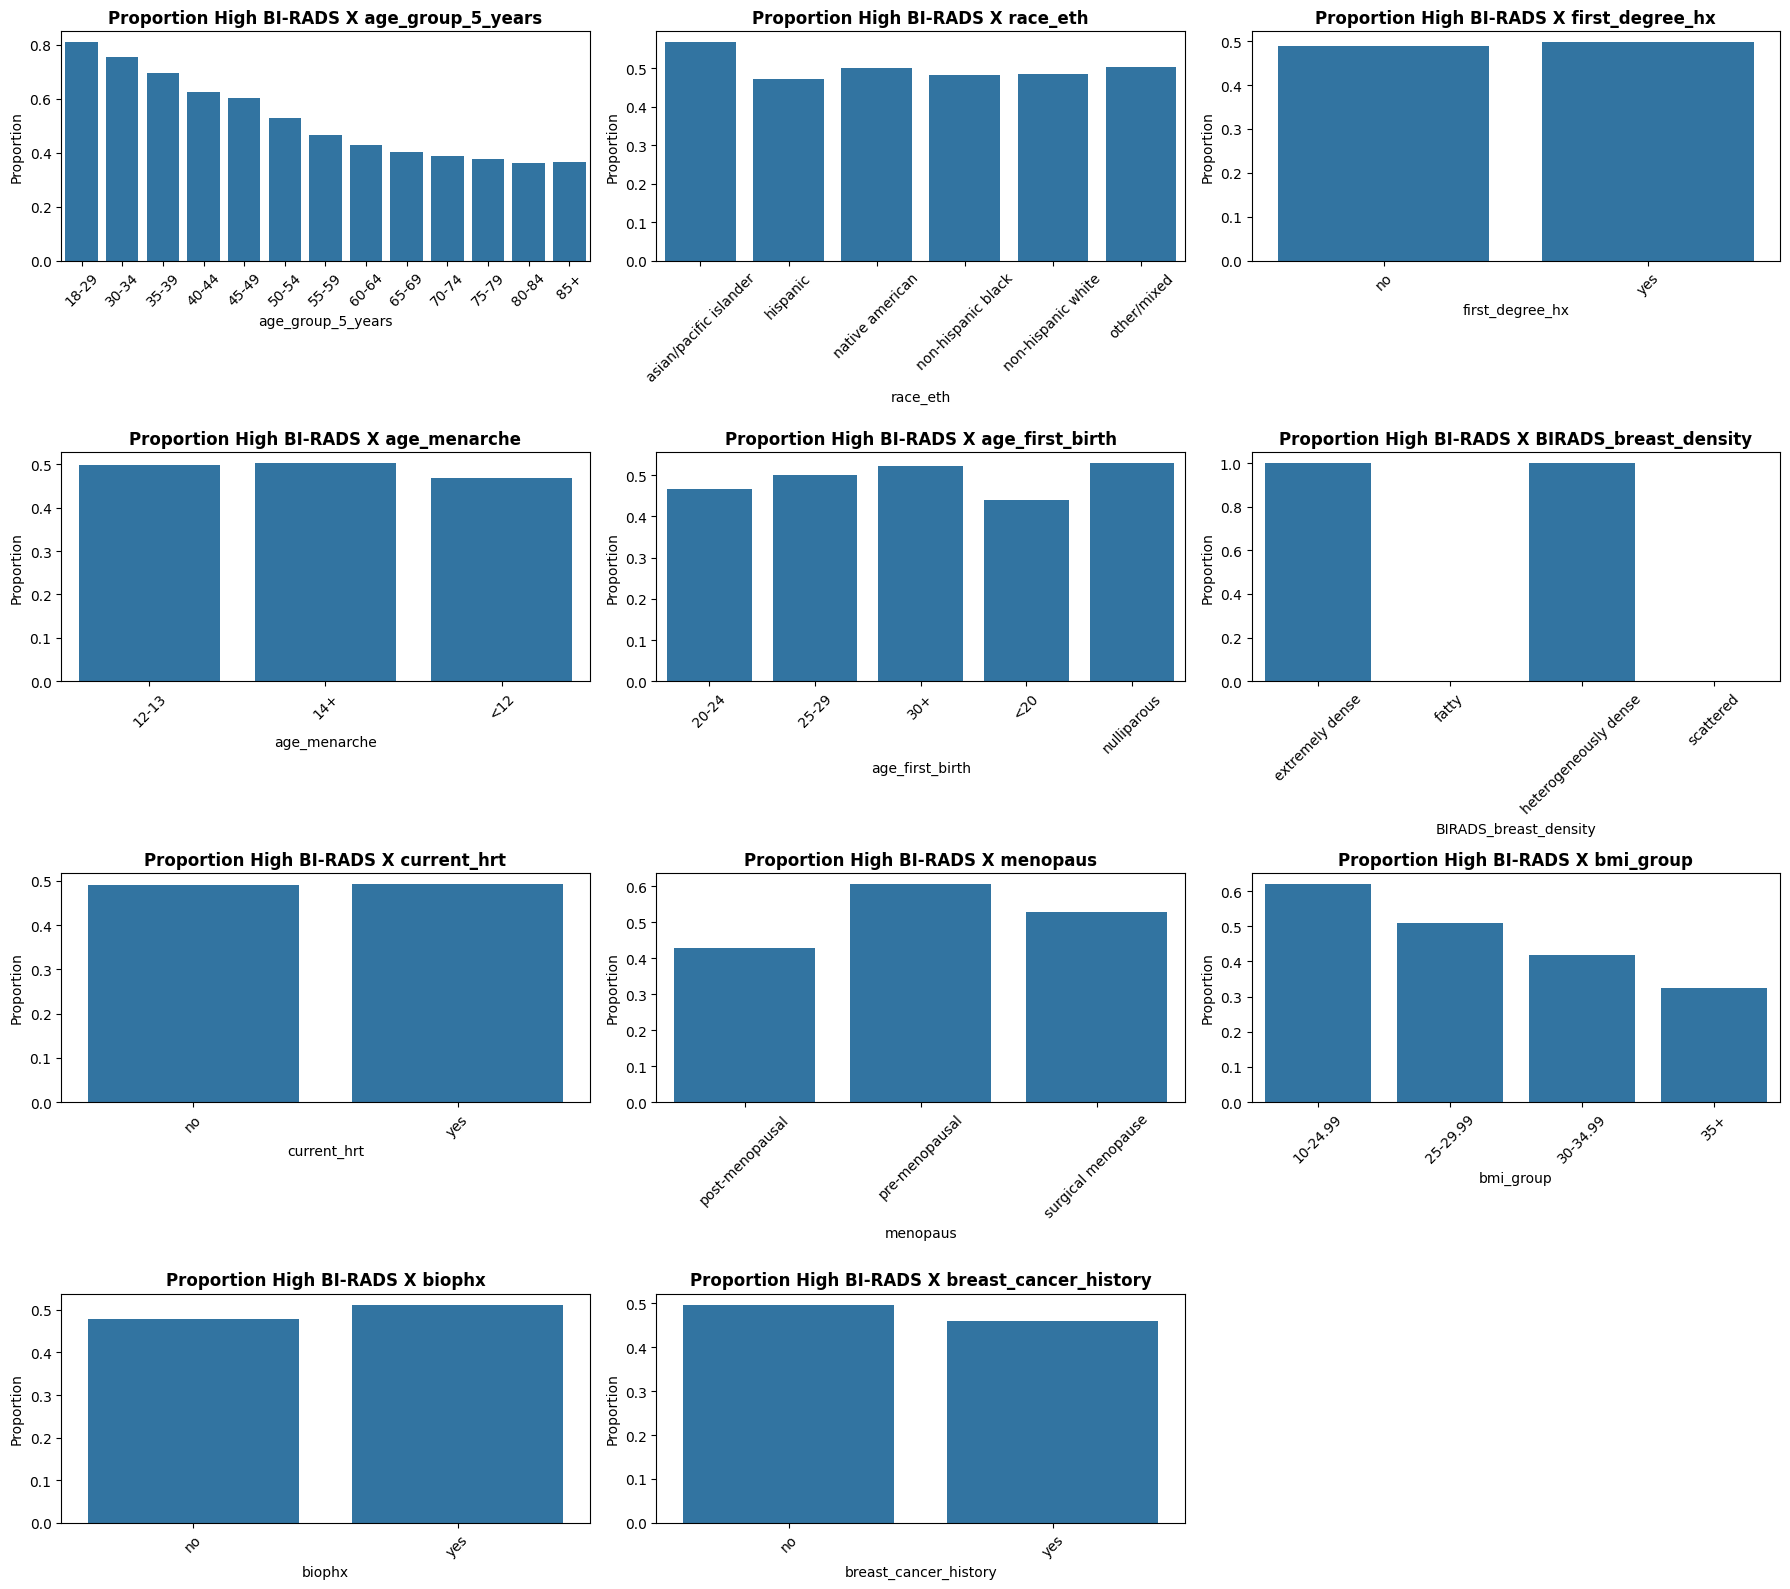

In [12]:
#Maintenant on veut voir comment les variables explicatives influencent les deux variables cibles (breast_cancer_hisotry et BIRADS_high)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    prop_data = df_cleaned.groupby(col)['BIRADS_high'].mean().reset_index()
    sns.barplot(data=prop_data, x=col, y='BIRADS_high', ax=axes[i])
    axes[i].set_title(f'Proportion High BI-RADS X {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Proportion')

# Supprimer les axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipython-input-1726444227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col)['breast_cancer_history_bin'].mean().reset_index()
/tmp/ipython-input-1726444227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col)['breast_cancer_history_bin'].mean().reset_index()
/tmp/ipython-input-1726444227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_d

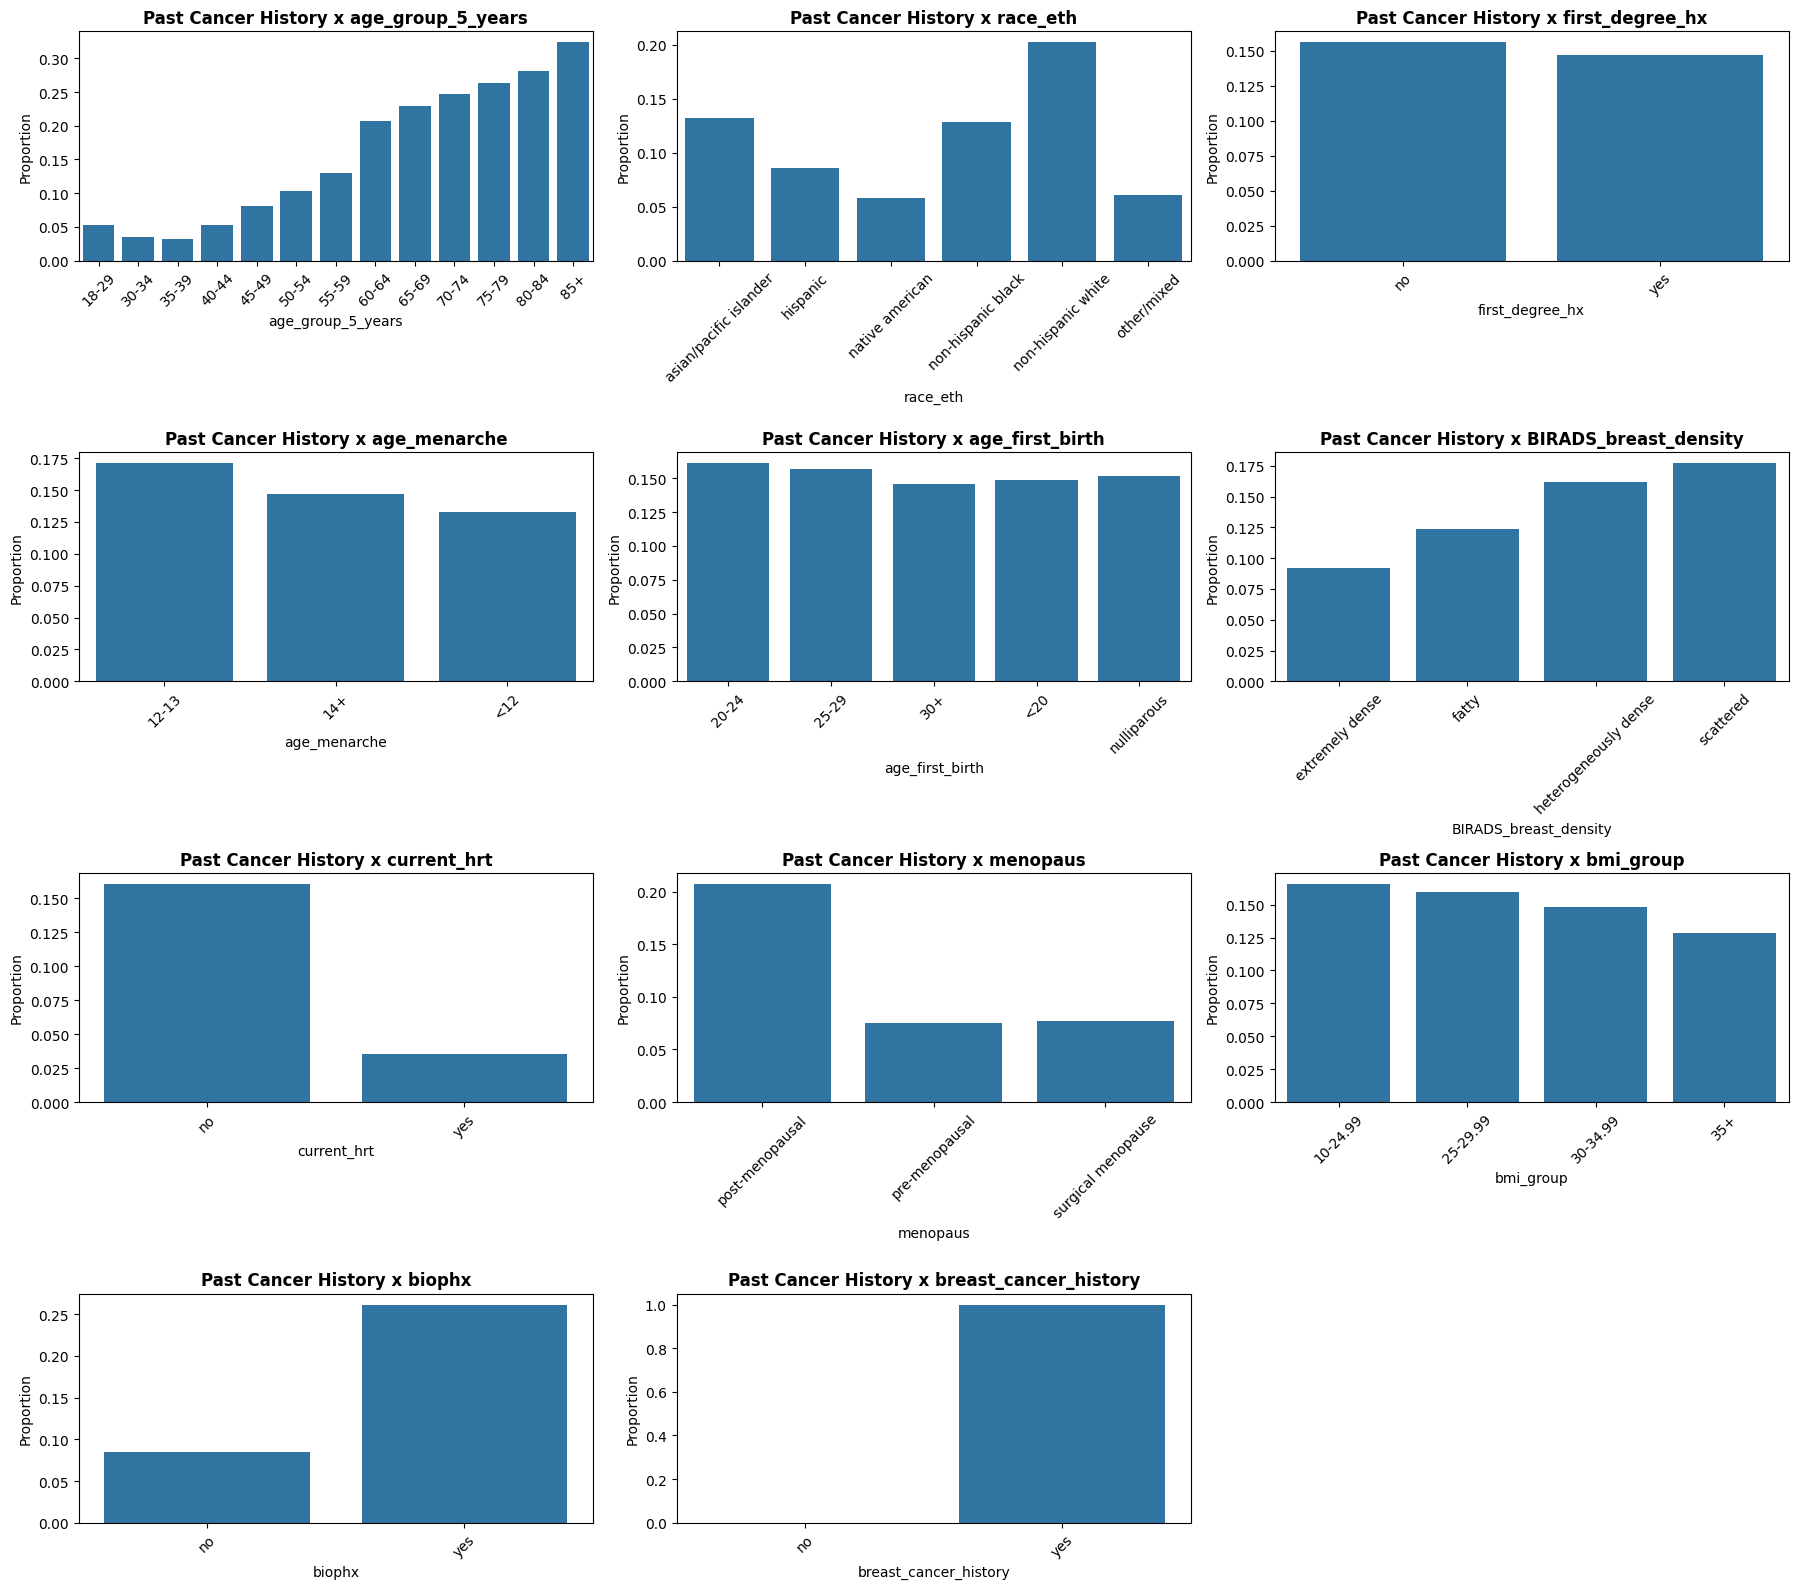

In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    prop_data = df_cleaned.groupby(col)['breast_cancer_history_bin'].mean().reset_index()
    sns.barplot(data=prop_data, x=col, y='breast_cancer_history_bin', ax=axes[i])
    axes[i].set_title(f'Past Cancer History x {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Proportion')

# Supprimer les axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipython-input-2314642578.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["age_code"] = df_cleaned["age_group_5_years"].map(age_order)
/tmp/ipython-input-2314642578.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["bmi_code"] = df_cleaned["bmi_group"].map(bmi_order)
/tmp/ipython-input-2314642578.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

,age_code,bmi_code,menopaus_code,family_code,birads_code,history_code
age_code,1.000000,-0.059195,0.684940,0.046004,-0.226876,0.218978
bmi_code,-0.059195,1.000000,-0.044981,-0.013766,-0.256822,-0.035486
menopaus_code,0.684940,-0.044981,1.000000,0.022287,-0.192770,0.169972
family_code,0.046004,-0.013766,0.022287,1.000000,0.011306,-0.011549
birads_code,-0.226876,-0.256822,-0.192770,0.011306,1.000000,-0.027893
history_code,0.218978,-0.035486,0.169972,-0.011549,-0.027893,1.000000


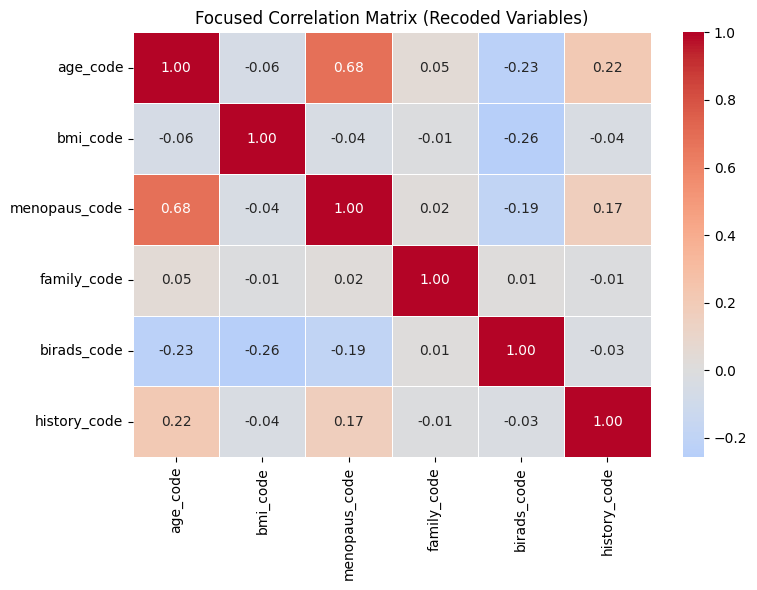

In [14]:
# -----------------------------------------------
# 1. Recode categories in a meaningful numerical order
# -----------------------------------------------

# Recode age groups in ascending order
age_order = {
    "18-29": 0, "30-34": 1, "35-39": 2, "40-44": 3,
    "45-49": 4, "50-54": 5, "55-59": 6, "60-64": 7,
    "65-69": 8, "70-74": 9, "75-79": 10, "80-84": 11, "85+": 12
}

# Recode BMI categories in ascending BMI
bmi_order = {
    "10-24.99": 0,
    "25-29.99": 1,
    "30-34.99": 2,
    "35+": 3
}

# Recode menopausal status logically: pre → surgical → post
menopause_order = {
    "pre-menopausal": 0,
    "surgical menopause": 1,
    "post-menopausal": 2
}

# Recode family history: no = 0, yes = 1
family_order = {
    "no": 0,
    "yes": 1
}

# Recode BI-RADS density (low → high)
birads_order = {
    "fatty": 0,
    "scattered": 1,
    "heterogeneously dense": 2,
    "extremely dense": 3
}

# Recode prior breast cancer history
history_order = {
    "no": 0,
    "yes": 1
}

# -----------------------------------------------
# 2. Apply recoding to the dataframe
# -----------------------------------------------

df_cleaned["age_code"] = df_cleaned["age_group_5_years"].map(age_order)
df_cleaned["bmi_code"] = df_cleaned["bmi_group"].map(bmi_order)
df_cleaned["menopaus_code"] = df_cleaned["menopaus"].map(menopause_order)
df_cleaned["family_code"] = df_cleaned["first_degree_hx"].map(family_order)
df_cleaned["birads_code"] = df_cleaned["BIRADS_breast_density"].map(birads_order)
df_cleaned["history_code"] = df_cleaned["breast_cancer_history"].map(history_order)

# -----------------------------------------------
# 3. Build the focused correlation dataframe
# -----------------------------------------------

df_corr = df_cleaned[[
    "age_code",
    "bmi_code",
    "menopaus_code",
    "family_code",
    "birads_code",
    "history_code"
]]

# Compute correlation matrix
corr_focus = df_corr.corr()
display(corr_focus)
# -----------------------------------------------
# 4. Plot the focused heatmap
# -----------------------------------------------

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_focus,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Focused Correlation Matrix (Recoded Variables)")
plt.tight_layout()
plt.show()

In [15]:
print(p_history)

0.061832788906364324


In [16]:
# ============================================================
# MODEL A — Logistic Regression for High Breast Density
# ============================================================

import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

df_modelA = df_cleaned.copy()

# Recode la variable dépendante : BIRADS_high = 1 si BI-RADS 3–4
df_modelA["BIRADS_high"] = df_modelA["BIRADS_breast_density"].isin(
    ["heterogeneously dense", "extremely dense"]
).astype(int)

# Modèle logit avec variables groupées et catégorielles
formula_A = """
BIRADS_high ~
    age_group_5_years +
    bmi_group +
    menopaus +
    age_first_birth +
    age_menarche +
    first_degree_hx
"""

modelA = smf.logit(formula_A, data=df_modelA).fit()
print(modelA.summary())

Optimization terminated successfully.
         Current function value: 0.644986
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            BIRADS_high   No. Observations:               345064
Model:                          Logit   Df Residuals:                   345039
Method:                           MLE   Df Model:                           24
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                 0.06930
Time:                        12:38:54   Log-Likelihood:            -2.2256e+05
converged:                       True   LL-Null:                   -2.3913e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          1.7563      0.093     18.880     

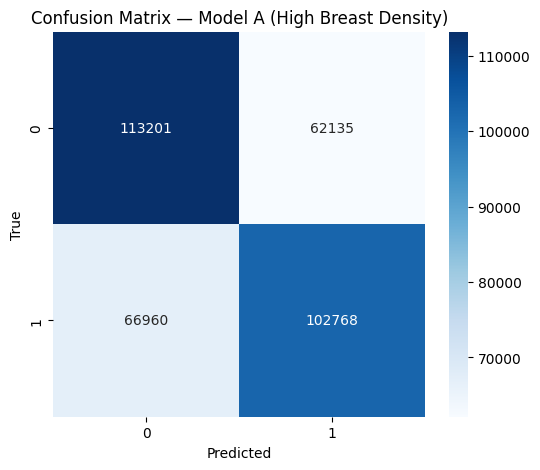


=== Classification Report (Model A) ===
              precision    recall  f1-score   support

           0       0.63      0.65      0.64    175336
           1       0.62      0.61      0.61    169728

    accuracy                           0.63    345064
   macro avg       0.63      0.63      0.63    345064
weighted avg       0.63      0.63      0.63    345064

Balanced Accuracy: 0.6256

=== F1 Scores (Model A) ===
F1 macro : 0.626
F1 weighted : 0.626
F1 class 1 : 0.614


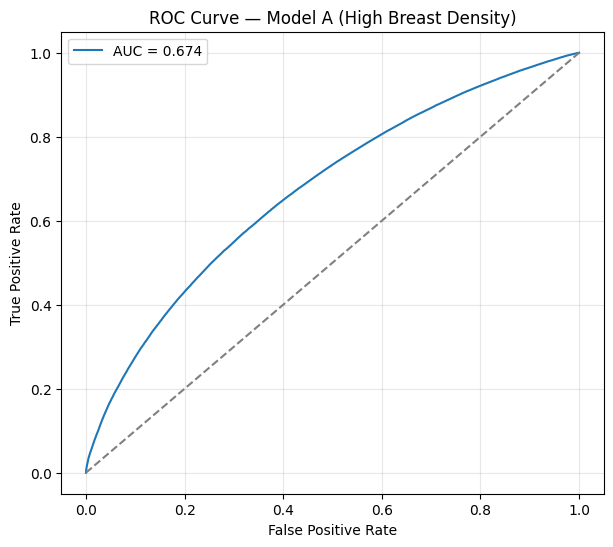


AUC (Model A): 0.674


In [31]:
# ===============================================================
#   Evaluation du MODELE A : High Breast Density (BIRADS_high)
# ===============================================================

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, f1_score, balanced_accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Récupérer les vraies valeurs et les prédictions ---
y_true_A = df_modelA["BIRADS_high"].astype(int)

# Probabilités prédites
y_pred_prob_A = modelA.predict()

# Classe prédite avec un seuil 0.5
y_pred_A = (y_pred_prob_A > 0.5).astype(int)

# --- 2. Matrice de confusion ---
cm_A = confusion_matrix(y_true_A, y_pred_A)

plt.figure(figsize=(6,5))
sns.heatmap(cm_A, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Model A (High Breast Density)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- 3. Classification Report ---
print("\n=== Classification Report (Model A) ===")
print(classification_report(y_true_A, y_pred_A))

# --- 4. Balanced Accuracy ---
bal_acc_A = balanced_accuracy_score(y_true_A, y_pred_A)
print("Balanced Accuracy:", round(bal_acc_A, 4))

# --- 5. F1-scores ---
f1_macro_A = f1_score(y_true_A, y_pred_A, average='macro')
f1_weighted_A = f1_score(y_true_A, y_pred_A, average='weighted')
f1_class1_A = f1_score(y_true_A, y_pred_A, average='binary')

print("\n=== F1 Scores (Model A) ===")
print("F1 macro :", round(f1_macro_A, 3))
print("F1 weighted :", round(f1_weighted_A, 3))
print("F1 class 1 :", round(f1_class1_A, 3))

# --- 6. ROC Curve + AUC ---
fpr, tpr, _ = roc_curve(y_true_A, y_pred_prob_A)
auc_A = roc_auc_score(y_true_A, y_pred_prob_A)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_A:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model A (High Breast Density)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nAUC (Model A):", round(auc_A, 3))

In [17]:
# Odds Ratios + IC 95%
paramsA = modelA.params
confA = modelA.conf_int()
or_table_A = pd.DataFrame({
    "coef": paramsA,
    "OR": np.exp(paramsA),
    "OR_2.5%": np.exp(confA[0]),
    "OR_97.5%": np.exp(confA[1])
})
print("\n=== Odds Ratios (Model A) ===")
print(or_table_A)


=== Odds Ratios (Model A) ===
                                    coef        OR   OR_2.5%  OR_97.5%
Intercept                       1.756322  5.791098  4.825867  6.949385
age_group_5_years[T.30-34]     -0.240033  0.786602  0.648878  0.953557
age_group_5_years[T.35-39]     -0.510297  0.600318  0.499509  0.721470
age_group_5_years[T.40-44]     -0.805848  0.446709  0.372550  0.535630
age_group_5_years[T.45-49]     -0.895304  0.408483  0.340798  0.489613
age_group_5_years[T.50-54]     -1.190540  0.304057  0.253685  0.364431
age_group_5_years[T.55-59]     -1.421324  0.241394  0.201351  0.289401
age_group_5_years[T.60-64]     -1.534735  0.215513  0.179538  0.258696
age_group_5_years[T.65-69]     -1.647562  0.192519  0.160363  0.231123
age_group_5_years[T.70-74]     -1.733396  0.176683  0.147129  0.212174
age_group_5_years[T.75-79]     -1.797106  0.165778  0.137976  0.199182
age_group_5_years[T.80-84]     -1.915786  0.147226  0.122399  0.177089
age_group_5_years[T.85+]       -1.976911  0.13

In [19]:
df_cleaned.columns.tolist()

['year',
 'age_group_5_years',
 'race_eth',
 'first_degree_hx',
 'age_menarche',
 'age_first_birth',
 'BIRADS_breast_density',
 'current_hrt',
 'menopaus',
 'bmi_group',
 'biophx',
 'breast_cancer_history',
 'count',
 'BIRADS_high',
 'breast_cancer_history_bin',
 'age_code',
 'bmi_code',
 'menopaus_code',
 'family_code',
 'birads_code',
 'history_code']

In [29]:
# ============================================================
# MODEL B — Logistic Regression for Prior Breast Cancer
# ============================================================

from imblearn.over_sampling import SMOTE
import statsmodels.api as sm

# Variable dépendante
# Garder une copie de la vérité terrain avant SMOTE
y_orig = y.copy()
y = df_cleaned["breast_cancer_history"].astype(str).str.lower().map({
    "yes": 1,
    "no": 0
}).fillna(0).astype(int)

# Variables explicatives
predictors_B = [
    "age_group_5_years",
    "bmi_group",
    "menopaus",
    "first_degree_hx",
    "age_first_birth",
    "age_menarche"     # ← bon nom de variable !
]

X = pd.get_dummies(df_cleaned[predictors_B], drop_first=True).astype(float)

# --- SMOTE to balance classes ---
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Ajouter constante
X_res = sm.add_constant(X_res)

# Fit du modèle logit
modelB = sm.Logit(y_res, X_res).fit()
print(modelB.summary())

Optimization terminated successfully.
         Current function value: 0.636458
         Iterations 6
                             Logit Regression Results                            
Dep. Variable:     breast_cancer_history   No. Observations:               584264
Model:                             Logit   Df Residuals:                   584239
Method:                              MLE   Df Model:                           24
Date:                   Mon, 08 Dec 2025   Pseudo R-squ.:                 0.08179
Time:                           12:54:59   Log-Likelihood:            -3.7186e+05
converged:                          True   LL-Null:                   -4.0498e+05
Covariance Type:               nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.8932      0.082 


=== F1 SCORES ===
F1 macro : 0.536
F1 weighted : 0.664
F1 classe 1 : 0.352

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.59      0.72    292132
           1       0.24      0.69      0.35     52932

    accuracy                           0.61    345064
   macro avg       0.58      0.64      0.54    345064
weighted avg       0.81      0.61      0.66    345064

Balanced Accuracy : 0.643


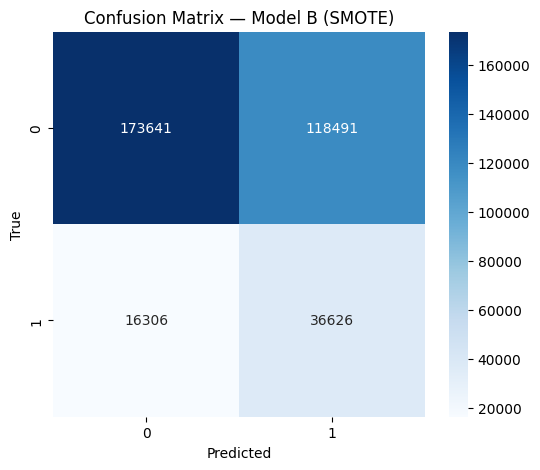

In [30]:
from sklearn.metrics import f1_score, classification_report, balanced_accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prédictions sur les données ORIGINALES (pas SMOTE)
# Recréer les X_orig proprement
X_orig = pd.get_dummies(df_cleaned[predictors_B], drop_first=True).astype(float)
X_orig = sm.add_constant(X_orig)

# Alignement des colonnes (important si SMOTE a créé des colonnes en plus)
X_orig = X_orig.reindex(columns=X_res.columns, fill_value=0)

# Prédictions
y_pred_prob = modelB.predict(X_orig)
y_pred_class = (y_pred_prob > 0.5).astype(int)

# --- 2. Scores
print("\n=== F1 SCORES ===")
print("F1 macro :", round(f1_score(y_orig, y_pred_class, average='macro'), 3))
print("F1 weighted :", round(f1_score(y_orig, y_pred_class, average='weighted'), 3))
print("F1 classe 1 :", round(f1_score(y_orig, y_pred_class, pos_label=1), 3))

# --- 3. Classification report
print("\n=== Classification Report ===")
print(classification_report(y_orig, y_pred_class))

# --- 4. Balanced accuracy
print("Balanced Accuracy :", round(balanced_accuracy_score(y_orig, y_pred_class), 3))

# --- 5. Matrice de confusion
cm = confusion_matrix(y_orig, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Model B (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [21]:
# Odds Ratios (Model B)
paramsB = modelB.params
confB = modelB.conf_int()
or_table_B = pd.DataFrame({
    "coef": paramsB,
    "OR": np.exp(paramsB),
    "OR_2.5%": np.exp(confB[0]),
    "OR_97.5%": np.exp(confB[1])
})
print("\n=== Odds Ratios (Model B — SMOTE) ===")
print(or_table_B)


=== Odds Ratios (Model B — SMOTE) ===
                                 coef        OR   OR_2.5%   OR_97.5%
const                       -0.893220  0.409336  0.348594   0.480661
age_group_5_years_30-34     -0.271085  0.762552  0.640297   0.908150
age_group_5_years_35-39     -0.315049  0.729753  0.618797   0.860605
age_group_5_years_40-44      0.203788  1.226038  1.043929   1.439916
age_group_5_years_45-49      0.671516  1.957202  1.667816   2.296800
age_group_5_years_50-54      0.916718  2.501068  2.131454   2.934777
age_group_5_years_55-59      1.167366  3.213516  2.738098   3.771480
age_group_5_years_60-64      1.579798  4.853974  4.132966   5.700764
age_group_5_years_65-69      1.697642  5.461056  4.649685   6.414012
age_group_5_years_70-74      1.814191  6.136110  5.223741   7.207830
age_group_5_years_75-79      1.887678  6.604017  5.620631   7.759455
age_group_5_years_80-84      1.970649  7.175334  6.103520   8.435366
age_group_5_years_85+        2.146509  8.554938  7.267621  10.07

AUC: 0.684


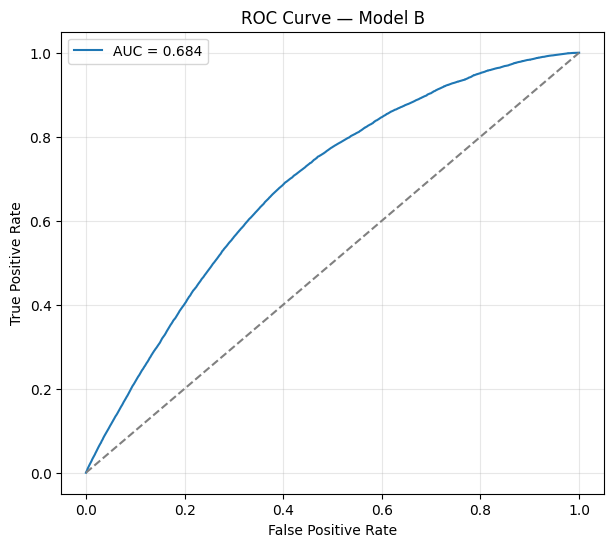

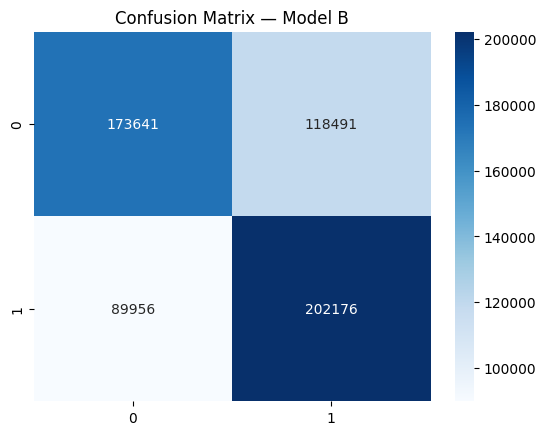

Balanced accuracy: 0.6432314843974641


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Prédictions ---
y_pred_prob = modelB.predict(X_res)
y_pred_class = (y_pred_prob > 0.5).astype(int)

# ---- AUC ----
auc_val = roc_auc_score(y_res, y_pred_prob)
print("AUC:", round(auc_val, 3))

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_res, y_pred_prob)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model B")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- Confusion matrix ----
cm = confusion_matrix(y_res, y_pred_class)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Model B")
plt.show()

# ---- Balanced Accuracy ----
print("Balanced accuracy:", balanced_accuracy_score(y_res, y_pred_class))